# Model Deep Learning UAS NLP Kelompok A

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud openpyxl iterstrat

ERROR: Could not find a version that satisfies the requirement iterstrat (from versions: none)
ERROR: No matching distribution found for iterstrat


In [4]:
import pandas as pd

df = pd.read_excel('/kaggle/input/data-sdgs/scrap_sdgs_unair.xlsx')
print(df.columns)
df.head()


Index(['Title', 'Authors', 'Year', 'Scopus Source title', 'Language',
       'Citations', 'Reference', 'Abstract', 'DOI', 'EID',
       'Sustainable Development Goals (2025)', 'abstract_text'],
      dtype='object')


,Title,Authors,Year,Scopus Source title,Language,Citations,Reference,Abstract,DOI,EID,Sustainable Development Goals (2025),abstract_text
0,"Global, regional, and national burden of osteo...","Steinmetz, J.D.| Culbreth, G.T.| Haile, L.M.| ...",2023.0,The Lancet Rheumatology,English,965.0,"Steinmetz, J.D., Culbreth, G.T., Haile, L.M. a...",https://www.scopus.com/record/display.uri?eid=...,10.1016/S2665-9913(23)00163-7,2-s2.0-85168323463,SDG 10,AbstractBackground: Osteoarthritis is the most...
1,Measuring universal health coverage based on a...,"Lozano, R.| Fullman, N.| Mumford, J.E.| Knight...",2020.0,The Lancet,English,511.0,"Lozano, R., Fullman, N., Mumford, J.E. and 774...",https://www.scopus.com/record/display.uri?eid=...,10.1016/S0140-6736(20)30750-9,2-s2.0-85090485900,SDG 3| SDG 10| SDG 12,AbstractBackground: Achieving universal health...
2,"Global, regional, and national progress toward...","Paulson, K.R.| Kamath, A.M.| Alam, T.| Bienhof...",2021.0,The Lancet,English,394.0,"Paulson, K.R., Kamath, A.M., Alam, T. and 736 ...",https://www.scopus.com/record/display.uri?eid=...,10.1016/S0140-6736(21)01207-1,2-s2.0-85114514329,SDG 1| SDG 3| SDG 4| SDG 10| SDG 12,AbstractBackground: Sustainable Development Go...
3,Global fertility in 204 countries and territor...,"Bhattacharjee, N.V.| Schumacher, A.E.| Aali, A...",2024.0,The Lancet,English,295.0,"Bhattacharjee, N.V., Schumacher, A.E., Aali, A...",https://www.scopus.com/record/display.uri?eid=...,10.1016/S0140-6736(24)00550-6,2-s2.0-85188450830,SDG 3| SDG 4| SDG 5| SDG 8| SDG 10,AbstractBackground: Accurate assessments of cu...
4,"Global, regional, and national incidence and m...","Bender, R.G.| Sirota, S.B.| Swetschinski, L.R....",2024.0,The Lancet Infectious Diseases,English,230.0,"Bender, R.G., Sirota, S.B., Swetschinski, L.R....",https://www.scopus.com/record/display.uri?eid=...,10.1016/S1473-3099(24)00176-2,2-s2.0-85191811208,SDG 1| SDG 3| SDG 10,AbstractBackground: Lower respiratory infectio...


In [5]:
import pandas as pd

df = pd.read_excel('/kaggle/input/data-sdgs/scrap_sdgs_unair.xlsx')

col = 'Sustainable Development Goals (2025)'

df[col].head(20)


0                                   SDG 10
1                    SDG 3| SDG 10| SDG 12
2      SDG 1| SDG 3| SDG 4| SDG 10| SDG 12
3       SDG 3| SDG 4| SDG 5| SDG 8| SDG 10
4                     SDG 1| SDG 3| SDG 10
5                     SDG 1| SDG 8| SDG 10
6                            SDG 3| SDG 10
7     SDG 7| SDG 8| SDG 10| SDG 11| SDG 15
8                            SDG 3| SDG 10
9                     SDG 1| SDG 8| SDG 10
10                                  SDG 10
11            SDG 1| SDG 8| SDG 10| SDG 13
12                           SDG 8| SDG 10
13                           SDG 3| SDG 10
14                    SDG 1| SDG 9| SDG 10
15                   SDG 9| SDG 10| SDG 12
16                           SDG 3| SDG 10
17                    SDG 3| SDG 5| SDG 10
18            SDG 7| SDG 8| SDG 10| SDG 13
19                           SDG 1| SDG 10
Name: Sustainable Development Goals (2025), dtype: object

## Exploratory Data Analysis

In [2]:
import os
import re
import json
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
import nltk
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud

from nltk.corpus import stopwords

# --------- CONFIG ----------
INPUT_PATH = '/kaggle/input/data-sdgs/scrap_sdgs_unair.xlsx'
OUTPUT_DIR = '/kaggle/working/'
TFIDF_TOP_N = 30
SAMPLE_PER_LABEL = 20
RANDOM_SEED = 42
# ---------------------------

np.random.seed(RANDOM_SEED)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. Load data
df = pd.read_excel(INPUT_PATH)
print("Loaded:", df.shape)

# 2. Basic cleaning & parse labels
label_col = 'Sustainable Development Goals (2025)'
text_col = 'abstract_text'
lang_col = 'Language'
year_col = 'Year'

def parse_labels(s):
    if pd.isna(s):
        return []
    parts = re.split(r'\||,|;', str(s))
    parts = [p.strip() for p in parts if p.strip()!='']
    return parts

df['parsed_sdgs'] = df[label_col].apply(parse_labels)
df[['Title', label_col, 'parsed_sdgs']].head(10).to_csv(os.path.join(OUTPUT_DIR, 'sample_parsed_labels.csv'), index=False)

# 3. Language distribution
lang_counts = df[lang_col].fillna('Unknown').value_counts()
lang_counts.to_csv(os.path.join(OUTPUT_DIR, 'language_distribution.csv'))
print("Language counts saved.")

# 4. Year distribution
if year_col in df.columns:
    year_counts = df[year_col].value_counts().sort_index()
    year_counts.to_csv(os.path.join(OUTPUT_DIR, 'year_distribution.csv'))
    print("Year counts saved.")

# 5. Label distribution (global)
all_labels = [l for labels in df['parsed_sdgs'] for l in labels]
label_counter = Counter(all_labels)
label_df = pd.DataFrame.from_records(list(label_counter.items()), columns=['SDG', 'count']).sort_values('count', ascending=False)
label_df.to_csv(os.path.join(OUTPUT_DIR, 'label_counts.csv'), index=False)

plt.figure(figsize=(12,6))
sns.barplot(data=label_df, x='SDG', y='count', palette='viridis')
plt.xticks(rotation=75)
plt.title('Label Distribution (All SDGs)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'label_distribution.png'))
plt.close()
print("Label distribution plot saved.")

# 6. Number of labels per document
df['n_labels'] = df['parsed_sdgs'].apply(len)
nlabels_counts = df['n_labels'].value_counts().sort_index()
nlabels_counts.to_csv(os.path.join(OUTPUT_DIR, 'nlabels_per_doc.csv'))

plt.figure(figsize=(6,4))
sns.histplot(df['n_labels'], bins=range(0, df['n_labels'].max()+2))
plt.title('Histogram: Number of labels per document')
plt.xlabel('Number of SDG labels')
plt.ylabel('Document count')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'nlabels_histogram.png'))
plt.close()
print("n_labels histogram saved.")

# 7. Co-occurrence matrix (pairwise)
mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(df['parsed_sdgs'])
labels = mlb.classes_
coocc = np.dot(Y.T, Y)  
coocc_df = pd.DataFrame(coocc, index=labels, columns=labels)
coocc_df.to_csv(os.path.join(OUTPUT_DIR, 'label_cooccurrence_matrix.csv'))

plt.figure(figsize=(10,8))
sns.heatmap(coocc_df, annot=False, cmap='magma')
plt.title('Label Co-occurrence Matrix (counts)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'label_cooccurrence_heatmap.png'))
plt.close()
print("Co-occurrence matrix and heatmap saved.")

# 8. Abstract length stats (chars & token counts)
def safe_text(x):
    if pd.isna(x):
        return ''
    return str(x)

df['abstract_text_clean'] = df[text_col].apply(safe_text)
df['abstract_len_chars'] = df['abstract_text_clean'].str.len()
stop_words = set(stopwords.words('english')) if 'english' in stopwords.fileids() else set()
def token_count(s):
    try:
        toks = word_tokenize(s)
        return len(toks)
    except Exception:
        return len(str(s).split())

df['abstract_len_tokens'] = df['abstract_text_clean'].apply(token_count)
df[['abstract_len_chars', 'abstract_len_tokens']].describe().to_csv(os.path.join(OUTPUT_DIR, 'abstract_length_stats.csv'))

plt.figure(figsize=(6,4))
sns.histplot(df['abstract_len_chars'], bins=50)
plt.title('Abstract length (characters)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'abstract_len_chars_hist.png'))
plt.close()

plt.figure(figsize=(6,4))
sns.histplot(df['abstract_len_tokens'], bins=50)
plt.title('Abstract length (tokens)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'abstract_len_tokens_hist.png'))
plt.close()
print("Abstract length plots + stats saved.")

# 9. Top TF-IDF terms per label
corpus = df['abstract_text_clean'].fillna('').astype(str).tolist()
vectorizer = TfidfVectorizer(max_df=0.9, min_df=2, stop_words='english', ngram_range=(1,2), max_features=40000)
X_tfidf = vectorizer.fit_transform(corpus)
feature_names = np.array(vectorizer.get_feature_names_out())

top_terms_per_label = []
for i, lab in enumerate(labels):
    idx = np.where(Y[:, i] == 1)[0]
    if len(idx) == 0:
        continue
    mean_tfidf = X_tfidf[idx,:].mean(axis=0).A1
    topn_idx = mean_tfidf.argsort()[::-1][:TFIDF_TOP_N]
    top_terms = feature_names[topn_idx].tolist()
    top_vals = mean_tfidf[topn_idx].tolist()
    for term, val in zip(top_terms, top_vals):
        top_terms_per_label.append({'SDG': lab, 'term': term, 'mean_tfidf': float(val)})
top_terms_df = pd.DataFrame(top_terms_per_label)
top_terms_df.to_csv(os.path.join(OUTPUT_DIR, 'top_tfidf_terms_per_label.csv'), index=False)
print("Top TF-IDF terms per label saved.")

# 10. Wordcloud per label (top 1-2 wordclouds; may be heavy)
wc_dir = os.path.join(OUTPUT_DIR, 'wordclouds')
os.makedirs(wc_dir, exist_ok=True)
for lab in labels:
    idx = np.where(Y[:, labels.tolist().index(lab)] == 1)[0]
    if len(idx) == 0:
        continue
    text_join = " ".join(df.iloc[idx]['abstract_text_clean'].astype(str).tolist())
    if len(text_join.strip()) < 20:
        continue
    wc = WordCloud(width=800, height=400, background_color='white', stopwords=set(stopwords.words('english'))).generate(text_join)
    wc.to_file(os.path.join(wc_dir, f'wordcloud_{lab.replace(" ", "_")}.png'))
print("Wordclouds saved (one per SDG where applicable).")

# 11. Save sample docs per label
samples = []
for lab in labels:
    idx = np.where(Y[:, labels.tolist().index(lab)] == 1)[0]
    if len(idx)==0:
        continue
    sel = df.iloc[idx].sample(n=min(SAMPLE_PER_LABEL, len(idx)), random_state=RANDOM_SEED)
    for _, row in sel.iterrows():
        samples.append({'SDG': lab, 'Title': row.get('Title',''), 'abstract': row['abstract_text_clean']})
samples_df = pd.DataFrame(samples)
samples_df.to_csv(os.path.join(OUTPUT_DIR, 'sample_docs_per_label.csv'), index=False)
print("Sample documents per label saved.")

# 12. Save binarized label matrix (for modelling)
binarized_df = pd.DataFrame(Y, columns=labels)
binarized_df.to_csv(os.path.join(OUTPUT_DIR, 'binarized_label_matrix.csv'), index=False)
print("Binarized label matrix saved.")

# 13. Save a final summary JSON
summary = {
    'n_rows': int(df.shape[0]),
    'n_columns': int(df.shape[1]),
    'n_unique_labels': int(len(labels)),
    'label_counts': label_counter,
    'nlabels_distribution': df['n_labels'].value_counts().to_dict(),
    'abstract_len_chars_stats': df['abstract_len_chars'].describe().to_dict(),
    'abstract_len_tokens_stats': df['abstract_len_tokens'].describe().to_dict()
}
with open(os.path.join(OUTPUT_DIR, 'summary.json'), 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)
print("Summary saved to summary.json")

print("All outputs saved in:", OUTPUT_DIR)


In [3]:
import os
import re
import json
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
import nltk
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from nltk.corpus import stopwords
import zipfile

# --------- CONFIG ----------
INPUT_PATH = '/kaggle/input/data-sdgs/scrap_sdgs_unair.xlsx'
OUTPUT_DIR = '/kaggle/working/eda_outputs'
TFIDF_TOP_N = 30
SAMPLE_PER_LABEL = 20
RANDOM_SEED = 42
# ---------------------------

np.random.seed(RANDOM_SEED)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. Load data
df = pd.read_excel(INPUT_PATH)
print("Loaded:", df.shape)

# 2. Basic cleaning & parse labels
label_col = 'Sustainable Development Goals (2025)'
text_col = 'abstract_text'
lang_col = 'Language'
year_col = 'Year'

def parse_labels(s):
    if pd.isna(s):
        return []
    # normalize separators & whitespace
    parts = re.split(r'\||,|;', str(s))
    parts = [p.strip() for p in parts if p.strip()!='']
    return parts

df['parsed_sdgs'] = df[label_col].apply(parse_labels)

df[['Title', label_col, 'parsed_sdgs']].head(10).to_csv(
    os.path.join(OUTPUT_DIR, 'sample_parsed_labels.csv'), index=False
)

# 3. Language distribution
lang_counts = df[lang_col].fillna('Unknown').value_counts()
lang_counts.to_csv(os.path.join(OUTPUT_DIR, 'language_distribution.csv'))
print("Language counts saved.")

# 4. Year distribution
if year_col in df.columns:
    year_counts = df[year_col].value_counts().sort_index()
    year_counts.to_csv(os.path.join(OUTPUT_DIR, 'year_distribution.csv'))
    print("Year counts saved.")

# 5. Label distribution
all_labels = [l for labels in df['parsed_sdgs'] for l in labels]
label_counter = Counter(all_labels)
label_df = pd.DataFrame(label_counter.items(), columns=['SDG', 'count']).sort_values('count', ascending=False)
label_df.to_csv(os.path.join(OUTPUT_DIR, 'label_counts.csv'), index=False)

plt.figure(figsize=(12,6))
sns.barplot(data=label_df, x='SDG', y='count', palette='viridis')
plt.xticks(rotation=75)
plt.title('Label Distribution (All SDGs)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'label_distribution.png'))
plt.close()

# 6. Number of labels per document
df['n_labels'] = df['parsed_sdgs'].apply(len)
df['n_labels'].value_counts().sort_index().to_csv(os.path.join(OUTPUT_DIR, 'nlabels_per_doc.csv'))

plt.figure(figsize=(6,4))
sns.histplot(df['n_labels'], bins=range(0, df['n_labels'].max()+2))
plt.title('Histogram: Number of labels per document')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'nlabels_histogram.png'))
plt.close()

# 7. Co-occurrence matrix
mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(df['parsed_sdgs'])
labels = mlb.classes_
coocc = np.dot(Y.T, Y)
coocc_df = pd.DataFrame(coocc, index=labels, columns=labels)
coocc_df.to_csv(os.path.join(OUTPUT_DIR, 'label_cooccurrence_matrix.csv'))

plt.figure(figsize=(10,8))
sns.heatmap(coocc_df, annot=False, cmap='magma')
plt.title('Label Co-occurrence Matrix (counts)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'label_cooccurrence_heatmap.png'))
plt.close()

# 8. Abstract length
def safe_text(x):
    return '' if pd.isna(x) else str(x)

df['abstract_text_clean'] = df[text_col].apply(safe_text)
df['abstract_len_chars'] = df['abstract_text_clean'].str.len()

def token_count(s):
    try:
        return len(word_tokenize(s))
    except:
        return len(str(s).split())

df['abstract_len_tokens'] = df['abstract_text_clean'].apply(token_count)

df[['abstract_len_chars', 'abstract_len_tokens']].describe().to_csv(
    os.path.join(OUTPUT_DIR, 'abstract_length_stats.csv')
)

plt.figure(figsize=(6,4))
sns.histplot(df['abstract_len_chars'], bins=50)
plt.title('Abstract length (characters)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'abstract_len_chars_hist.png'))
plt.close()

plt.figure(figsize=(6,4))
sns.histplot(df['abstract_len_tokens'], bins=50)
plt.title('Abstract length (tokens)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'abstract_len_tokens_hist.png'))
plt.close()

# 9. Top TF-IDF terms per label
corpus = df['abstract_text_clean'].tolist()
vectorizer = TfidfVectorizer(
    max_df=0.9, min_df=2, stop_words='english',
    ngram_range=(1,2), max_features=40000
)
X_tfidf = vectorizer.fit_transform(corpus)
feature_names = np.array(vectorizer.get_feature_names_out())

top_terms_per_label = []
for i, lab in enumerate(labels):
    idx = np.where(Y[:, i] == 1)[0]
    if len(idx) == 0: continue
    mean_tfidf = X_tfidf[idx,:].mean(axis=0).A1
    topn_idx = mean_tfidf.argsort()[::-1][:TFIDF_TOP_N]
    for term, val in zip(feature_names[topn_idx], mean_tfidf[topn_idx]):
        top_terms_per_label.append({
            'SDG': lab,
            'term': term,
            'mean_tfidf': float(val)
        })

pd.DataFrame(top_terms_per_label).to_csv(
    os.path.join(OUTPUT_DIR, 'top_tfidf_terms_per_label.csv'),
    index=False
)

# 10. Wordclouds
wc_dir = os.path.join(OUTPUT_DIR, 'wordclouds')
os.makedirs(wc_dir, exist_ok=True)

english_stopwords = set(stopwords.words('english'))

for lab in labels:
    idx = np.where(Y[:, labels.tolist().index(lab)] == 1)[0]
    if len(idx) == 0:
        continue
    text_join = " ".join(df.iloc[idx]['abstract_text_clean'].tolist())
    if len(text_join.strip()) < 20:
        continue
    wc = WordCloud(
        width=800, height=400, background_color='white',
        stopwords=english_stopwords
    ).generate(text_join)
    wc.to_file(os.path.join(wc_dir, f'wordcloud_{lab}.png'))

# 11. Sample docs per label
samples = []
for lab in labels:
    idx = np.where(Y[:, labels.tolist().index(lab)] == 1)[0]
    if len(idx)==0: continue
    sel = df.iloc[idx].sample(n=min(SAMPLE_PER_LABEL, len(idx)), random_state=RANDOM_SEED)
    for _, row in sel.iterrows():
        samples.append({
            'SDG': lab,
            'Title': row.get('Title', ''),
            'abstract': row['abstract_text_clean']
        })

pd.DataFrame(samples).to_csv(
    os.path.join(OUTPUT_DIR, 'sample_docs_per_label.csv'),
    index=False
)

# 12. Save binarized matrix
pd.DataFrame(Y, columns=labels).to_csv(
    os.path.join(OUTPUT_DIR, 'binarized_label_matrix.csv'),
    index=False
)

# 13. Summary JSON
summary = {
    'n_rows': int(df.shape[0]),
    'n_columns': int(df.shape[1]),
    'n_unique_labels': int(len(labels)),
    'label_counts': label_counter,
    'nlabels_distribution': df['n_labels'].value_counts().to_dict(),
    'abstract_len_chars_stats': df['abstract_len_chars'].describe().to_dict(),
    'abstract_len_tokens_stats': df['abstract_len_tokens'].describe().to_dict()
}
with open(os.path.join(OUTPUT_DIR, 'summary.json'), 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)

print("All EDA outputs saved to:", OUTPUT_DIR)


## Zip All Output

In [ ]:
ZIP_PATH = '/kaggle/working/sdgs_eda_outputs.zip'
print("Zipping all outputs to:", ZIP_PATH)

with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(OUTPUT_DIR):
        for f in files:
            full_path = os.path.join(root, f)
            arcname = os.path.relpath(full_path, OUTPUT_DIR)
            zipf.write(full_path, arcname)

print("ZIP file created successfully:", ZIP_PATH)

# Training Pipeline

## 0. Import Library

In [26]:
import os
import re
import math
import random
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

from typing import List, Optional

import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score, precision_recall_fscore_support, hamming_loss

In [27]:
# --------------------- Kaggle paths & config ---------------------
INPUT_PATH = '/kaggle/input/data-sdgs/scrap_sdgs_unair.xlsx'
OUTPUT_DIR = '/kaggle/working/'
MODEL_SAVE_PATH = os.path.join(OUTPUT_DIR, 'best_model.pt')
THRESHOLDS_PATH = os.path.join(OUTPUT_DIR, 'thresholds.npy')
TOKENIZER_DIR = os.path.join(OUTPUT_DIR, 'tokenizer')

SEED = 42
MODEL_NAME = "xlm-roberta-base"
BATCH_SIZE = 16
MAX_LENGTH = 256
EPOCHS = 20
LR = 2e-5
NUM_WORKERS = 2
DROPOUT = 0.1
PATIENCE = 3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed()

## 2. Data Loader & Parsing

In [28]:
def load_data_from_excel(path: str):
    df = pd.read_excel(path)
    df.columns = [c.strip() for c in df.columns]

    col_map = {c.lower(): c for c in df.columns}

    if 'abstract_text' in col_map:
        abstract_col = col_map['abstract_text']
    elif 'abstract' in col_map:
        abstract_col = col_map['abstract']
    else:
        raise ValueError("No abstract/abstract_text column found.")

    title_col = col_map.get('title', None)
    label_col_candidates = [k for k in df.columns if 'sustainable' in k.lower() and 'goal' in k.lower()]
    if not label_col_candidates:
        raise ValueError("Label column (Sustainable Development Goals) not found.")
    label_col = label_col_candidates[0]

    if title_col:
        df['text'] = df[title_col].astype(str).fillna("") + ". " + df[abstract_col].astype(str).fillna("")
    else:
        df['text'] = df[abstract_col].astype(str).fillna("")

    def parse_cell(x):
        if pd.isna(x):
            return []
        s = str(x)
        nums = re.findall(r"SDG\s*0*(\d+)", s, flags=re.IGNORECASE)
        if not nums:
            nums = re.findall(r"\b0*(\d{1,2})\b", s)
        nums = [int(n) for n in nums]
        return sorted(set(nums))

    df['labels_raw'] = df[label_col].apply(parse_cell)
    df = df[['text', 'labels_raw']].rename(columns={'labels_raw': 'labels'}).reset_index(drop=True)
    return df

class SDGDataset(Dataset):
    def __init__(self, texts: List[str], labels: List[List[int]], tokenizer, max_len: int = MAX_LENGTH):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        enc = self.tokenizer(text,
                             truncation=True,
                             max_length=self.max_len,
                             padding='max_length',
                             return_tensors='pt')
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item['labels'] = torch.FloatTensor(self.labels[idx])
        return item

## 3. Model

In [29]:
class LabelAttentionHead(nn.Module):
    def __init__(self, hidden_size: int, num_labels: int, label_emb_dim: Optional[int] = None, dropout: float = 0.1):
        super().__init__()
        self.label_emb_dim = label_emb_dim or hidden_size
        self.label_embeddings = nn.Parameter(torch.randn(num_labels, self.label_emb_dim) * 0.02)
        self.doc_proj = nn.Linear(hidden_size, self.label_emb_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, doc_rep: torch.Tensor):
        proj = self.doc_proj(doc_rep)  # (B, D)
        logits = torch.matmul(proj, self.label_embeddings.t()) 
        return logits

class MultiLabelModelB(nn.Module):
    def __init__(self, backbone_name: str, num_labels: int, label_emb_dim: Optional[int] = None, dropout: float = 0.1):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(backbone_name)
        hidden_size = self.backbone.config.hidden_size
        self.pooler = lambda x: x.last_hidden_state[:, 0, :]
        self.head = LabelAttentionHead(hidden_size, num_labels, label_emb_dim=label_emb_dim, dropout=dropout)

    def forward(self, input_ids, attention_mask):
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        rep = self.pooler(outputs)
        logits = self.head(rep)
        return logits

## 4. Loss: ASL

In [30]:
class AsymmetricLoss(nn.Module):
    def __init__(self, gamma_pos: float = 0.0, gamma_neg: float = 4.0, clip: float = 0.05, eps: float = 1e-8, reduction: str = "mean"):
        super().__init__()
        self.gamma_pos = gamma_pos
        self.gamma_neg = gamma_neg
        self.clip = clip
        self.eps = eps
        self.reduction = reduction

    def forward(self, logits, targets):
        x_sigmoid = torch.sigmoid(logits)
        xs_pos = x_sigmoid
        xs_neg = 1.0 - x_sigmoid

        if self.clip is not None and self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1)

        loss_pos = targets * torch.log(xs_pos.clamp(min=self.eps))
        loss_neg = (1.0 - targets) * torch.log(xs_neg.clamp(min=self.eps))
        loss = - loss_pos - loss_neg

        if self.gamma_neg > 0 or self.gamma_pos > 0:
            pt = xs_pos * targets + xs_neg * (1 - targets)
            gamma = self.gamma_pos * targets + self.gamma_neg * (1 - targets)
            loss = loss * ((1 - pt) ** gamma)

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:
            return loss

## 5. Sampler & Utils 

In [31]:
def get_sampler(y: np.ndarray):
    per_label_freq = y.sum(axis=0)
    inv_label_freq = 1.0 / (per_label_freq + 1e-6)
    sample_weights = (y * inv_label_freq).sum(axis=1)
    sample_weights = sample_weights + 1e-6
    sample_weights = sample_weights / sample_weights.mean()
    sample_weights = torch.DoubleTensor(sample_weights)
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
    return sampler

def tune_thresholds(probs: np.ndarray, targets: np.ndarray, search_space: Optional[np.ndarray] = None) -> np.ndarray:
    if search_space is None:
        search_space = np.linspace(0.05, 0.9, 86)
    n_labels = probs.shape[1]
    best_thr = np.zeros(n_labels)
    for i in range(n_labels):
        best_f1 = -1
        best_t = 0.5
        p = probs[:, i]
        t = targets[:, i]
        for thr in search_space:
            pred = (p >= thr).astype(int)
            f1 = f1_score(t, pred, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_t = thr
        best_thr[i] = best_t
    return best_thr

def evaluate(model, dataloader, device, threshold: Optional[np.ndarray] = None):
    model.eval()
    preds = []
    targets = []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].cpu().numpy()
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds.append(probs)
            targets.append(labels)
    preds = np.vstack(preds)
    targets = np.vstack(targets)
    if threshold is None:
        thr = np.full(preds.shape[1], 0.5)
    else:
        thr = threshold
    bin_preds = (preds >= thr.reshape(1, -1)).astype(int)
    micro_f1 = f1_score(targets.flatten(), bin_preds.flatten(), average="micro", zero_division=0)
    macro_f1 = f1_score(targets, bin_preds, average="macro", zero_division=0)
    per_label = precision_recall_fscore_support(targets, bin_preds, average=None, zero_division=0)
    ham_loss = hamming_loss(targets, bin_preds)
    return {
        "micro_f1": micro_f1,
        "macro_f1": macro_f1,
        "per_label": per_label,
        "hamming_loss": ham_loss,
        "probs": preds,
        "targets": targets,
    }

## 6. Main Training Pipeline

In [32]:
def train_pipeline():
    df = load_data_from_excel(INPUT_PATH)
    all_label_numbers = sorted({num for labs in df['labels'] for num in labs})
    if len(all_label_numbers) == 0:
        raise ValueError("No labels parsed. Check label column formatting.")
    label_map = {lab: idx for idx, lab in enumerate(all_label_numbers)}
    df['labels_idx'] = df['labels'].apply(lambda labs: [label_map[l] for l in labs if l in label_map])

    mlb = MultiLabelBinarizer(classes=range(len(all_label_numbers)))
    Y = mlb.fit_transform(df['labels_idx'])
    X = df['text'].tolist()

    n = len(X)
    idx = np.arange(n)
    np.random.shuffle(idx)
    train_end = int(0.8 * n)
    val_end = int(0.9 * n)
    train_idx, val_idx, test_idx = idx[:train_end], idx[train_end:val_end], idx[val_end:]

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    Path(TOKENIZER_DIR).mkdir(parents=True, exist_ok=True)
    tokenizer.save_pretrained(TOKENIZER_DIR)

    train_texts = [X[i] for i in train_idx]
    val_texts = [X[i] for i in val_idx]
    test_texts = [X[i] for i in test_idx]
    train_labels = Y[train_idx].tolist()
    val_labels = Y[val_idx].tolist()
    test_labels = Y[test_idx].tolist()

    train_dataset = SDGDataset(train_texts, train_labels, tokenizer, max_len=MAX_LENGTH)
    val_dataset = SDGDataset(val_texts, val_labels, tokenizer, max_len=MAX_LENGTH)
    test_dataset = SDGDataset(test_texts, test_labels, tokenizer, max_len=MAX_LENGTH)

    sampler = get_sampler(np.array(train_labels))
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    model = MultiLabelModelB(MODEL_NAME, num_labels=len(all_label_numbers), label_emb_dim=None, dropout=DROPOUT)
    model.to(DEVICE)

    loss_fn = AsymmetricLoss(gamma_pos=0.0, gamma_neg=4.0, clip=0.05)
    optimizer = AdamW(model.parameters(), lr=LR)
    total_steps = len(train_loader) * EPOCHS
    scheduler = OneCycleLR(optimizer, max_lr=LR, total_steps=total_steps, pct_start=0.1)

    best_macro = -1.0
    patience_ctr = 0

    history = {
        "epoch": [],
        "train_loss": [],
        "val_micro": [],
        "val_macro": [],
        "lr": []
    }

    for epoch in range(1, EPOCHS + 1):
        model.train()
        losses = []
        tk = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False)
        for batch in tk:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            optimizer.zero_grad()
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            losses.append(loss.item())
            tk.set_postfix({"loss": np.mean(losses)})

        val_res = evaluate(model, val_loader, DEVICE)
        print(f"Epoch {epoch} | TrainLoss {np.mean(losses):.4f} | Val microF1 {val_res['micro_f1']:.4f} | Val macroF1 {val_res['macro_f1']:.4f}")

        score = val_res['macro_f1']
        if score > best_macro:
            best_macro = score
            patience_ctr = 0
            torch.save({
                "model_state": model.state_dict(),
                "label_map": label_map,
                "all_label_numbers": all_label_numbers
            }, MODEL_SAVE_PATH)
            print(f"Saved best model (macro_f1={best_macro:.4f}) to {MODEL_SAVE_PATH}")
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print("Early stopping triggered.")
                break

    chk = torch.load(MODEL_SAVE_PATH, map_location=DEVICE)
    model.load_state_dict(chk["model_state"])

    val_eval = evaluate(model, val_loader, DEVICE)
    val_probs = val_eval["probs"]
    val_targets = val_eval["targets"]
    thresholds = tune_thresholds(val_probs, val_targets)
    np.save(THRESHOLDS_PATH, thresholds)

    test_eval = evaluate(model, test_loader, DEVICE, threshold=thresholds)
    print("Final Test micro F1:", test_eval["micro_f1"])
    print("Final Test macro F1:", test_eval["macro_f1"])
    prec, rec, f1, sup = test_eval["per_label"]
    for i, labnum in enumerate(chk["all_label_numbers"]):
        print(f"Label SDG {labnum} -> P {prec[i]:.3f} R {rec[i]:.3f} F1 {f1[i]:.3f} Support {int(sup[i])}")

    artifact = {
        "thresholds": thresholds,
        "label_map": chk["label_map"],
        "all_label_numbers": chk["all_label_numbers"]
    }
    torch.save(artifact, os.path.join(OUTPUT_DIR, "model_metadata.pt"))
    print("Saved thresholds and metadata to", OUTPUT_DIR)

In [33]:
if __name__ == "__main__":
    train_pipeline()

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Epoch 1 | TrainLoss 0.1021 | Val microF1 0.8516 | Val macroF1 0.3995
Saved best model (macro_f1=0.3995) to /kaggle/working/best_model.pt


Epoch 2 | TrainLoss 0.0652 | Val microF1 0.9169 | Val macroF1 0.5173
Saved best model (macro_f1=0.5173) to /kaggle/working/best_model.pt


...

Epoch 16 | TrainLoss 0.0009 | Val microF1 0.9591 | Val macroF1 0.6508


Epoch 17 | TrainLoss 0.0009 | Val microF1 0.9606 | Val macroF1 0.6649
Saved best model (macro_f1=0.6649) to /kaggle/working/best_model.pt


Epoch 18 | TrainLoss 0.0007 | Val microF1 0.9593 | Val macroF1 0.6593


Epoch 19 | TrainLoss 0.0007 | Val microF1 0.9596 | Val macroF1 0.6611


Epoch 20 | TrainLoss 0.0007 | Val microF1 0.9594 | Val macroF1 0.6604
Early stopping triggered.
Final Test micro F1: 0.9743641774891775
Final Test macro F1: 0.7168137636645134
Label SDG 1 -> P 0.824 R 0.560 F1 0.667 Support 25
Label SDG 2 -> P 0.857 R 0.769 F1 0.811 Support 39
Label SDG 3 -> P 0.971 R 0.963 F1 0.967 Support 628
Label SDG 4 -> P 0.684 R 0.464 F1 0.553 Support 28
Label SDG 5 -> P 0.540 R 0.675 F1 0.600 Support 40
Label SDG 6 -> P 0.730 R 0.675 F1 0.701 Support 40
Label SDG 7 -> P 0.900 R 0.957 F1 0.928 Support 47
Label SDG 8 -> P 0.655 R 0.590 F1 0.621 Support 61
Label SDG 9 -> P 0.561 R 0.571 F1 0.566 Support 56
Label SDG 10 -> P 0.562 R 0.692 F1 0.621 Support 39
Label SDG 11 -> P 0.520 R 0.867 F1 0.650 Support 15
Label SDG 12 -> P 0.769 R 0.556 F1 0.645 Support 54
Label SDG 13 -> P 0.850 R 0.944 F1 0.895 Support 18
Label SDG 14 -> P 0.692 R 1.000 F1 0.818 Support 36
Label SDG 15 -> P 0.846 R 0.550 F1 0.667 Support 20
Label SDG 16 -> P 0.789 R 0.732 F1 0.759 Support 41


## Fungsi Visualisasi

In [41]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

from transformers import AutoTokenizer
from torch.utils.data import DataLoader

In [42]:
OUTPUT_DIR = "/kaggle/working/"
MODEL_SAVE_PATH = os.path.join(OUTPUT_DIR, "best_model.pt")
THRESHOLDS_PATH = os.path.join(OUTPUT_DIR, "thresholds.npy")
TOKENIZER_DIR = os.path.join(OUTPUT_DIR, "tokenizer")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

chk = torch.load(MODEL_SAVE_PATH, map_location=DEVICE)
thresholds = np.load(THRESHOLDS_PATH)

label_map = chk["label_map"]
all_label_numbers = chk["all_label_numbers"]
num_labels = len(all_label_numbers)

In [43]:
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_DIR)

model = MultiLabelModelB(
    backbone_name="xlm-roberta-base",
    num_labels=num_labels
)
model.load_state_dict(chk["model_state"])
model.to(DEVICE)
model.eval()

MultiLabelModelB(
  (backbone): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
  

In [44]:
df = load_data_from_excel(INPUT_PATH)

df["labels_idx"] = df["labels"].apply(
    lambda labs: [label_map[l] for l in labs if l in label_map]
)

mlb = MultiLabelBinarizer(classes=range(num_labels))
Y = mlb.fit_transform(df["labels_idx"])
X = df["text"].tolist()

n = len(X)
idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)

train_end = int(0.8 * n)
val_end = int(0.9 * n)

val_idx = idx[train_end:val_end]
test_idx = idx[val_end:]

val_dataset = SDGDataset(
    [X[i] for i in val_idx],
    Y[val_idx].tolist(),
    tokenizer
)

test_dataset = SDGDataset(
    [X[i] for i in test_idx],
    Y[test_idx].tolist(),
    tokenizer
)

val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

val_texts = [X[i] for i in val_idx]
test_texts = [X[i] for i in test_idx]

In [45]:
val_eval = evaluate(model, val_loader, DEVICE)
test_eval = evaluate(model, test_loader, DEVICE, threshold=thresholds)

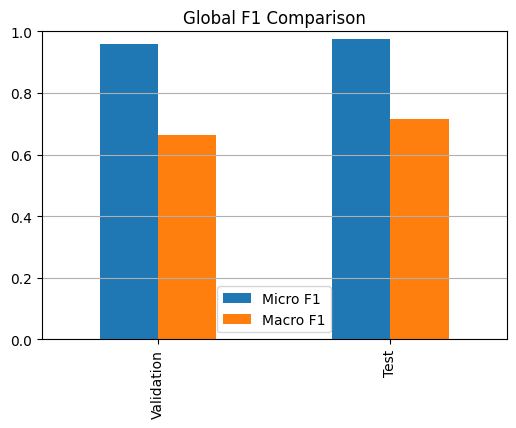

In [46]:
def plot_global_f1(val_eval, test_eval):
    df = pd.DataFrame({
        "Micro F1": [val_eval["micro_f1"], test_eval["micro_f1"]],
        "Macro F1": [val_eval["macro_f1"], test_eval["macro_f1"]],
    }, index=["Validation", "Test"])

    df.plot(kind="bar", figsize=(6,4))
    plt.title("Global F1 Comparison")
    plt.ylim(0,1)
    plt.grid(axis="y")
    plt.show()

plot_global_f1(val_eval, test_eval)

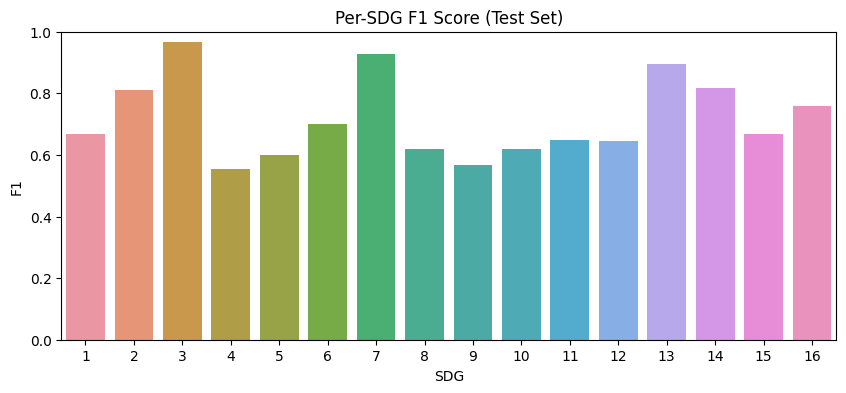

In [47]:
def plot_per_label_f1(eval_res, label_numbers):
    _, _, f1, support = eval_res["per_label"]

    df = pd.DataFrame({
        "SDG": label_numbers,
        "F1": f1,
        "Support": support
    })

    plt.figure(figsize=(10,4))
    sns.barplot(data=df, x="SDG", y="F1")
    plt.title("Per-SDG F1 Score (Test Set)")
    plt.ylim(0,1)
    plt.show()

plot_per_label_f1(test_eval, all_label_numbers)


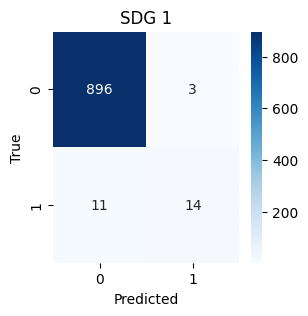

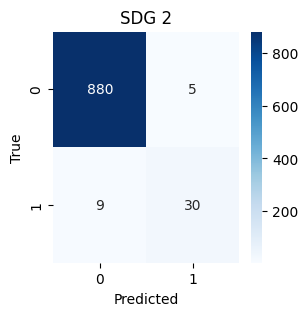

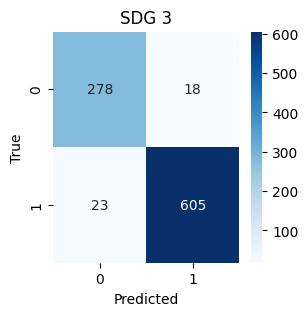

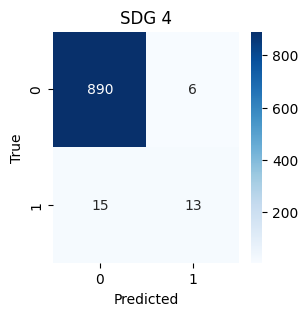

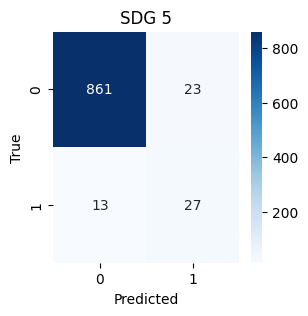

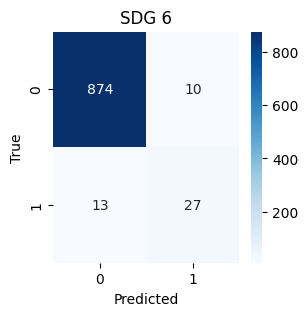

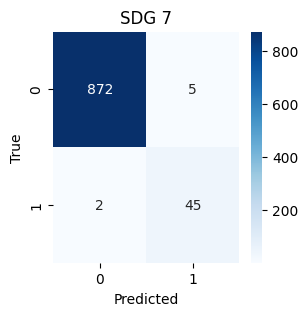

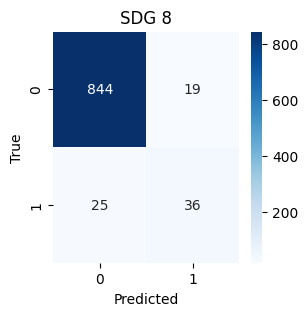

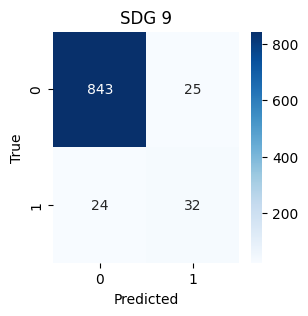

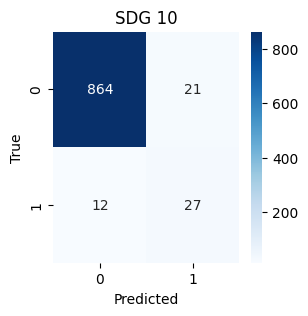

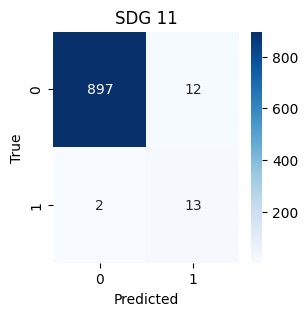

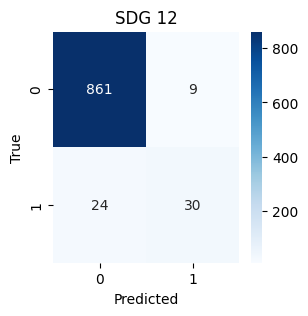

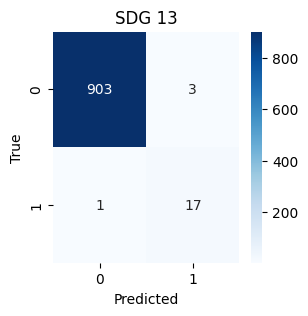

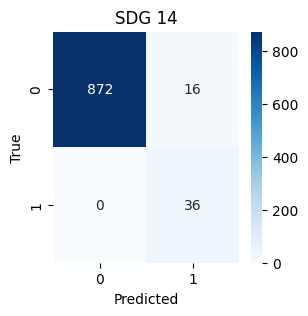

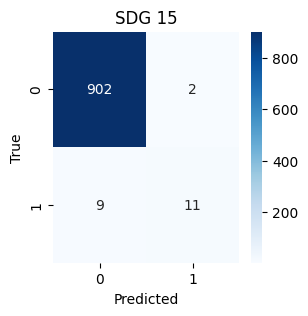

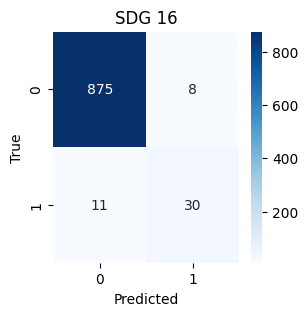

In [56]:
def plot_confusion_matrices(eval_res, label_numbers, thresholds):
    probs = eval_res["probs"]
    targets = eval_res["targets"]
    preds = (probs >= thresholds.reshape(1,-1)).astype(int)

    for i, sdg in enumerate(label_numbers):
        cm = confusion_matrix(targets[:,i], preds[:,i])
        plt.figure(figsize=(3,3))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title(f"SDG {sdg}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.show()

plot_confusion_matrices(test_eval, all_label_numbers, thresholds)

In [49]:
report = classification_report(
    test_eval["targets"],
    (test_eval["probs"] >= thresholds.reshape(1,-1)).astype(int),
    target_names=[f"SDG {i}" for i in all_label_numbers],
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

       SDG 1       0.82      0.56      0.67        25
       SDG 2       0.86      0.77      0.81        39
       SDG 3       0.97      0.96      0.97       628
       SDG 4       0.68      0.46      0.55        28
       SDG 5       0.54      0.68      0.60        40
       SDG 6       0.73      0.68      0.70        40
       SDG 7       0.90      0.96      0.93        47
       SDG 8       0.65      0.59      0.62        61
       SDG 9       0.56      0.57      0.57        56
      SDG 10       0.56      0.69      0.62        39
      SDG 11       0.52      0.87      0.65        15
      SDG 12       0.77      0.56      0.65        54
      SDG 13       0.85      0.94      0.89        18
      SDG 14       0.69      1.00      0.82        36
      SDG 15       0.85      0.55      0.67        20
      SDG 16       0.79      0.73      0.76        41

   micro avg       0.84      0.84      0.84      1187
   macro avg       0.73   

In [50]:
def error_analysis(eval_res, texts, label_numbers, thresholds, top_k=2):
    probs = eval_res["probs"]
    targets = eval_res["targets"]
    preds = (probs >= thresholds.reshape(1,-1)).astype(int)

    for i, sdg in enumerate(label_numbers):
        fn = np.where((targets[:,i]==1) & (preds[:,i]==0))[0]
        fp = np.where((targets[:,i]==0) & (preds[:,i]==1))[0]

        print(f"\n=== SDG {sdg} ===")
        print(f"FN: {len(fn)} | FP: {len(fp)}")

        for idx in fn[:top_k]:
            print("[FN]", texts[idx][:250], "...")
        for idx in fp[:top_k]:
            print("[FP]", texts[idx][:250], "...")

error_analysis(test_eval, test_texts, all_label_numbers, thresholds)


=== SDG 1 ===
FN: 11 | FP: 3
[FN] The Indonesian Government’s Dilemma in Repatriating Former ISIS Members: Balancing Advocacy, Citizenship Status, and Human Rights. AbstractIndonesian Government confronts a multifaceted challenge in repatriating former ISIS members, necessitating a d ...
[FN] The effects of pension plans on audit pricing: Evidence from Indonesia. AbstractThe purpose of this study is to investigate the effect of pension plans on audit fees. The research population is 487 observations from 263 companies listed in the Indone ...
[FP] Economic evaluation of trastuzumab in HER2-positive early breast cancer in Indonesia: A cost-effectiveness analysis. AbstractBackground Trastuzumab has significantly enhanced the survival and prognosis of individuals diagnosed with human epidermal gr ...
[FP] Increasing number of young unemployment due to inflation, education, and economic growth. AbstractThis study aimed to determine the effect of economic growth, inflation rates, education